<a href="https://colab.research.google.com/github/ElsaMolina/Cursos_EstadisticasConPython/blob/main/Optimizaci%C3%B3n_aeroporturaria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
import pandas as pd

In [57]:
datos =pd.read_csv('/content/flights.csv')
datos.head()

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609
2,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,0,2010,False,2.388305
3,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,0,2010,False,19.138491
4,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,0,2010,False,15.016271


In [58]:
datos.shape

(71175, 11)

In [59]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   flight_id       71175 non-null  int64  
 1   airline         71175 non-null  object 
 2   aircraft_type   71175 non-null  object 
 3   schengen        71175 non-null  object 
 4   origin          71175 non-null  object 
 5   arrival_time    71175 non-null  float64
 6   departure_time  71175 non-null  float64
 7   day             71175 non-null  int64  
 8   year            71175 non-null  int64  
 9   is_holiday      71175 non-null  bool   
 10  delay           71175 non-null  float64
dtypes: bool(1), float64(3), int64(3), object(4)
memory usage: 5.5+ MB


In [60]:
datos.describe(include='O')

,airline,aircraft_type,schengen,origin
count,71175,71175,71175,71175
unique,3,6,2,10
top,BZ,Airbus A320,schengen,TZF
freq,47598,30778,42569,14162


In [61]:
import seaborn as sns
import matplotlib.pyplot as plt


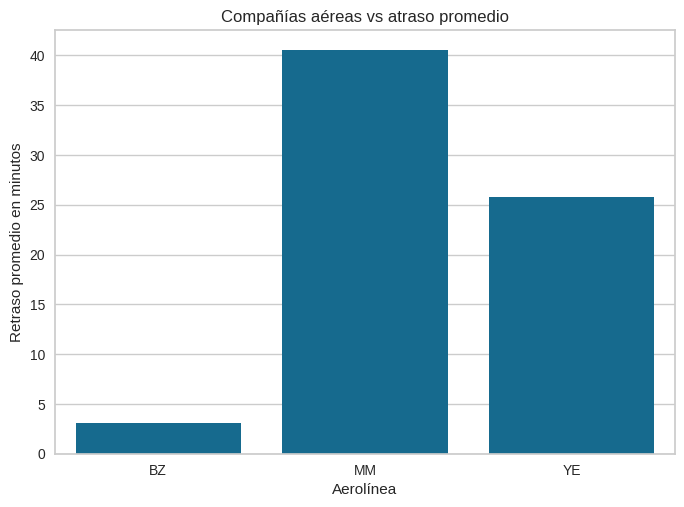

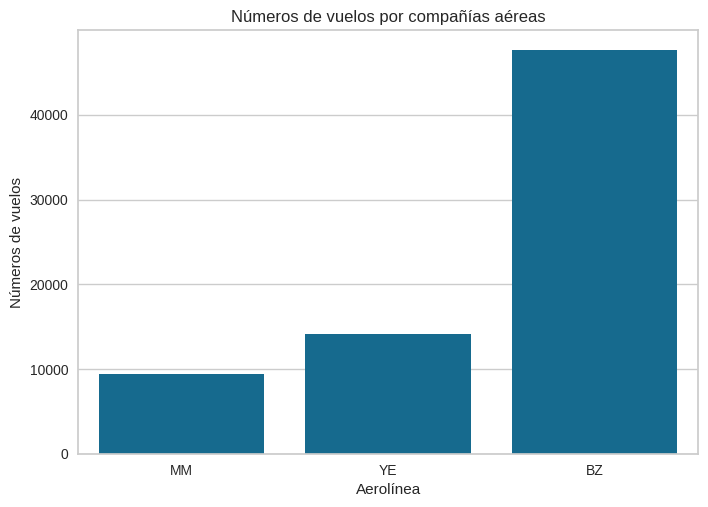

In [62]:
avg_delay = datos.groupby('airline')['delay'].mean().reset_index()
sns.barplot(x='airline', y='delay', data=avg_delay)
plt.title ('Compañías aéreas vs atraso promedio')
plt.xlabel('Aerolínea')
plt.ylabel('Retraso promedio en minutos')
plt.show()

sns.countplot(x='airline', data=datos)
plt.title('Números de vuelos por compañías aéreas')
plt.xlabel('Aerolínea')
plt.ylabel('Números de vuelos')
plt.show()

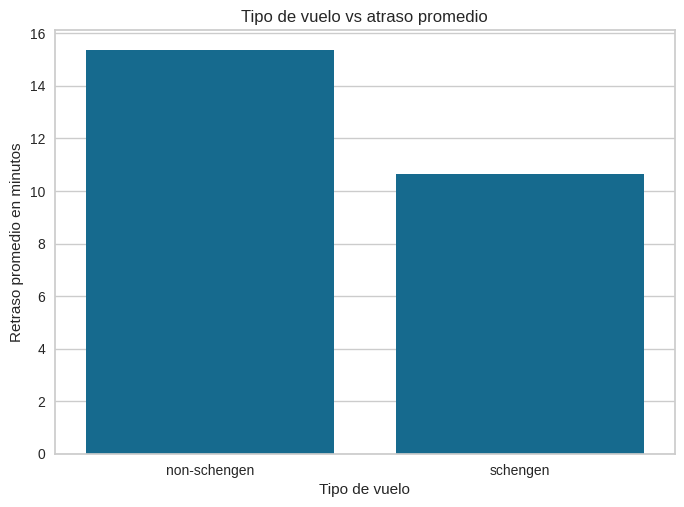

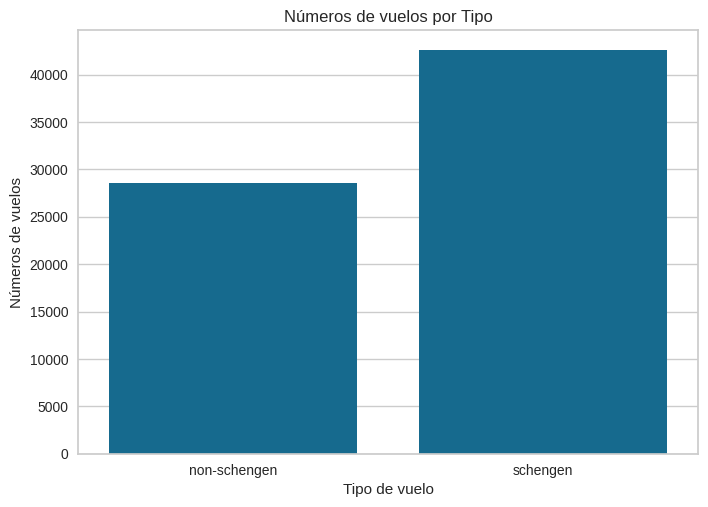

In [63]:
avg_delay = datos.groupby('schengen')['delay'].mean().reset_index()
sns.barplot(x='schengen', y='delay', data=avg_delay)
plt.title ('Tipo de vuelo vs atraso promedio')
plt.xlabel('Tipo de vuelo')
plt.ylabel('Retraso promedio en minutos')
plt.show()

sns.countplot(x='schengen', data=datos)
plt.title('Números de vuelos por Tipo')
plt.xlabel('Tipo de vuelo')
plt.ylabel('Números de vuelos')
plt.show()

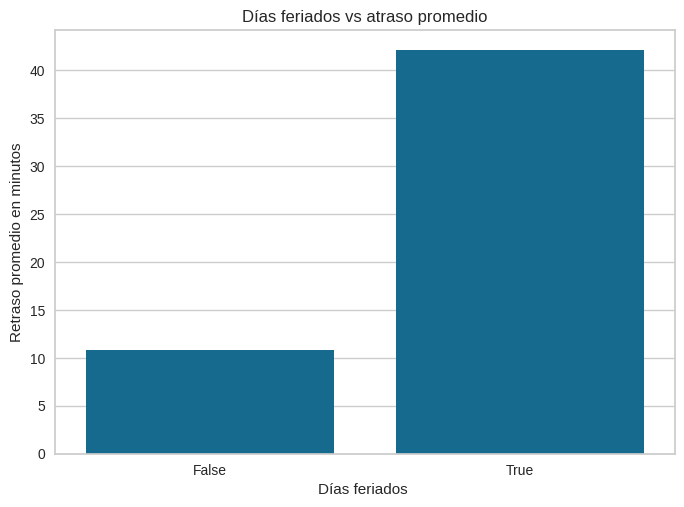

In [64]:
avg_delay = datos.groupby('is_holiday')['delay'].mean().reset_index()
sns.barplot(x='is_holiday', y='delay', data=avg_delay)
plt.title ('Días feriados vs atraso promedio')
plt.xlabel('Días feriados ')
plt.ylabel('Retraso promedio en minutos')
plt.show()

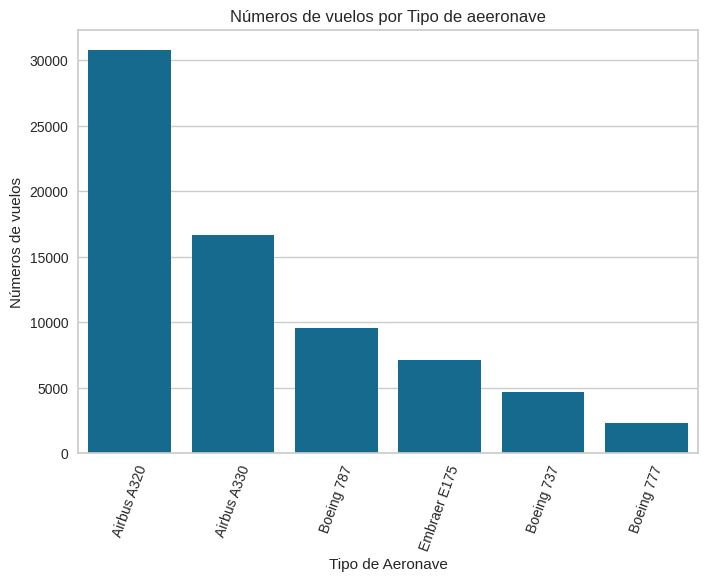

In [65]:
order =datos['aircraft_type'].value_counts().index
sns.countplot(x='aircraft_type', data=datos, order=order)
plt.title('Números de vuelos por Tipo de aeeronave')
plt.xticks(rotation=70)
plt.xlabel('Tipo de Aeronave')
plt.ylabel('Números de vuelos')
plt.show()

<Axes: xlabel='arrival_time', ylabel='Count'>

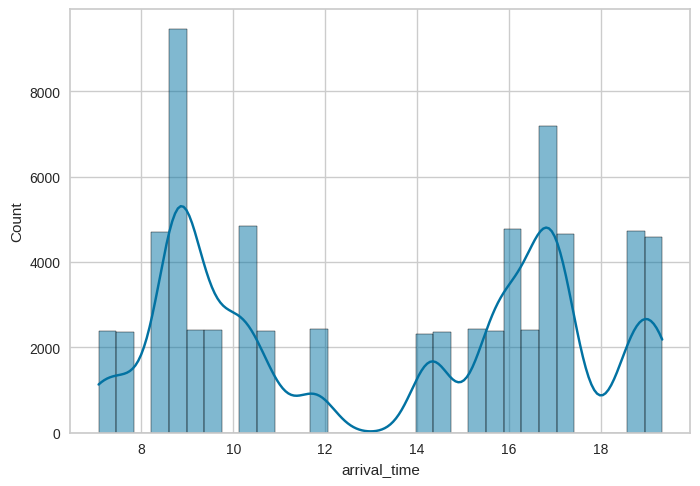

In [66]:
sns.histplot(data =datos, x='arrival_time', kde=True)

In [67]:
import numpy as np

def ancho_bin(df,columna):
  q75,q25 =np.percentile(df[columna],[75,25])
  iqr=q75-q25
  ancho=2*iqr * np.power(len(df[columna]), -1/3)
  return ancho

<Axes: xlabel='arrival_time', ylabel='Count'>

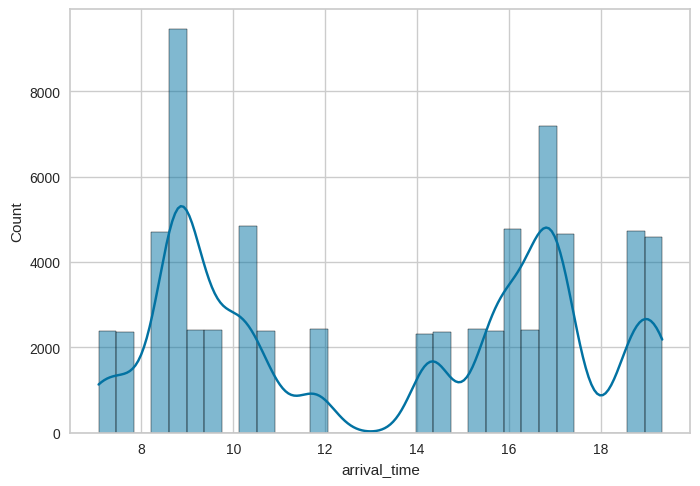

In [68]:
binwidth = ancho_bin(datos, 'arrival_time' )
sns.histplot(data=datos, x='arrival_time', kde= True, binwidth = binwidth)

<Axes: xlabel='departure_time', ylabel='Count'>

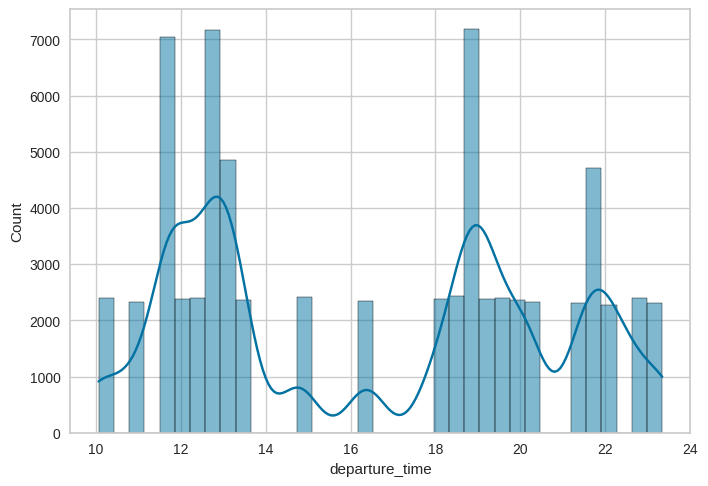

In [69]:
binwidth = ancho_bin(datos, 'departure_time' )
sns.histplot(data=datos, x='departure_time', kde= True, binwidth = binwidth)

AttributeError: Line2D.set() got an unexpected keyword argument 'y'

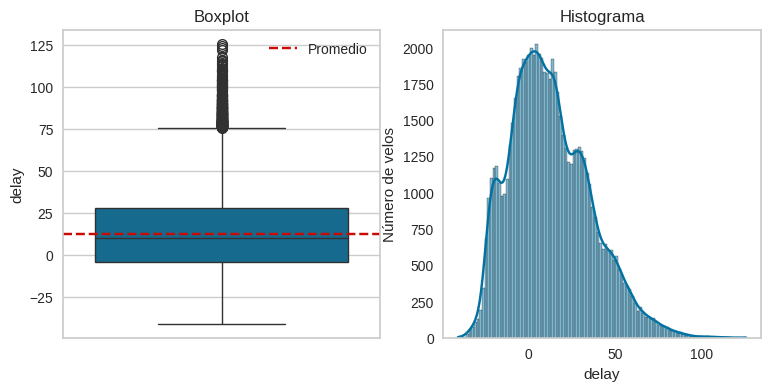

In [70]:
atraso_promedio = datos['delay'].mean()
atraso_mediana = datos['delay'].median()

fig,ax= plt.subplots(1,2, figsize=(9,4))

sns.boxplot(data=datos, y='delay', ax=ax[0])
ax[0].set_title('Boxplot')
ax[0].axhline(y=atraso_promedio, color='r', linestyle='--', label='Promedio')
ax[0].legend()

binwidth= ancho_bin(datos,'delay')
sns.histplot(data=datos, x='delay', ax=ax[1], kde=True,binwidth=binwidth)
plt.ylabel('Número de velos')
plt.grid(False)
ax[1].set_title('Histograma')
ax[1].axvline(y=atraso_promedio, color ='r', linestyle='--', label='Promedio')
ax[1].axvline(x=atraso_mediana, color ='y', linestyle='--', label='Mediana')
ax[1].legend()

plt.tight_layout()
plt.show()



## Feature engineering

In [71]:
datos.columns

Index(['flight_id', 'airline', 'aircraft_type', 'schengen', 'origin',
       'arrival_time', 'departure_time', 'day', 'year', 'is_holiday', 'delay'],
      dtype='object')

In [72]:
datos['date']=datos['year'].astype(str)+ '-'+ (datos['day']+1).astype(str)
datos['date']= pd.to_datetime(datos['date'],format = '%Y-%j')
datos.head(2)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981,2010-01-01
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609,2010-01-01


In [73]:
datos['is_weekend'] = datos['date'].dt.weekday.isin([5, 6])
datos['day_name'] = datos['date'].dt.day_name()

In [74]:
datos.sample(5)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
3133,4,BZ,Airbus A330,schengen,TCY,11.781391,14.781391,208,2010,False,-15.401621,2010-07-28,False,Wednesday
375,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,25,2010,False,-18.470444,2010-01-26,False,Tuesday
22226,19,MM,Airbus A320,schengen,TZF,16.245220,19.245220,21,2014,False,61.290316,2014-01-22,False,Wednesday
1899,22,YE,Airbus A320,non-schengen,MWL,8.794147,11.794147,126,2010,False,45.754319,2010-05-07,False,Friday
32425,8,BZ,Airbus A320,schengen,ZQO,15.729617,18.729617,336,2015,False,2.531365,2015-12-03,False,Thursday


In [75]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   flight_id       71175 non-null  int64         
 1   airline         71175 non-null  object        
 2   aircraft_type   71175 non-null  object        
 3   schengen        71175 non-null  object        
 4   origin          71175 non-null  object        
 5   arrival_time    71175 non-null  float64       
 6   departure_time  71175 non-null  float64       
 7   day             71175 non-null  int64         
 8   year            71175 non-null  int64         
 9   is_holiday      71175 non-null  bool          
 10  delay           71175 non-null  float64       
 11  date            71175 non-null  datetime64[ns]
 12  is_weekend      71175 non-null  bool          
 13  day_name        71175 non-null  object        
dtypes: bool(2), datetime64[ns](1), float64(3), int64(3), o

In [76]:
import warnings
warnings.filterwarnings('ignore')

In [77]:
datos['schengen'] = datos['schengen'].replace({'non-schengen': 0, 'schengen': 1})
datos['is_holiday'] = datos['is_holiday'].replace({False: 0, True: 1})
datos['is_weekend'] = datos['is_weekend'].replace({False: 0, True: 1})
datos.sample(5)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
60120,9,BZ,Airbus A330,0,TZF,10.733469,12.733469,358,2020,0,-22.326071,2020-12-24,0,Thursday
40823,28,BZ,Airbus A330,0,EMM,15.967963,17.967963,166,2017,0,-15.915568,2017-06-16,0,Friday
24079,3,BZ,Embraer E175,1,TZF,18.635384,22.635384,145,2014,0,-26.768622,2014-05-26,0,Monday
32215,17,BZ,Airbus A330,0,CNU,16.718722,21.718722,322,2015,0,19.497665,2015-11-19,0,Thursday
41956,25,BZ,Boeing 777,0,CSF,19.341235,23.341235,242,2017,0,14.236279,2017-08-31,0,Thursday


In [78]:
variables_categoricas = ['airline', 'aircraft_type', 'origin', 'day_name']
df_encoded = pd.get_dummies(data=datos, columns=variables_categoricas, dtype=int)
df_encoded.sample(3)

,flight_id,schengen,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
15869,27,1,14.376052,16.376052,327,2012,0,-2.182329,2012-11-23,0,...,0,0,0,1,0,0,0,0,0,0
50171,26,0,8.885071,10.885071,59,2019,0,31.249866,2019-03-01,0,...,1,0,0,1,0,0,0,0,0,0
29610,17,0,16.718722,21.718722,149,2015,0,-2.363675,2015-05-30,1,...,0,0,0,0,0,1,0,0,0,0


In [80]:
datos[['arrival_time','departure_time']].corr()

,arrival_time,departure_time
arrival_time,1.000000,0.973797
departure_time,0.973797,1.000000


In [81]:
df= df_encoded.drop(columns=['flight_id','departure_time','day','year','date'])
df.sample(10)

,schengen,arrival_time,is_holiday,delay,is_weekend,airline_BZ,airline_MM,airline_YE,aircraft_type_Airbus A320,aircraft_type_Airbus A330,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
33785,0,16.718722,0,11.801386,0,1,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
57852,0,17.041281,0,54.654722,1,0,1,0,1,0,...,0,0,0,0,0,1,0,0,0,0
34766,0,15.967963,0,-15.926428,1,1,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
21646,1,18.635384,0,-13.986865,1,1,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
63509,0,8.939996,0,33.902814,1,0,0,1,1,0,...,1,0,0,0,0,1,0,0,0,0
2380,1,15.729617,0,-0.325171,0,1,0,0,1,0,...,0,0,1,0,0,0,0,0,1,0
16457,1,7.065594,0,15.403400,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4003,0,8.885071,0,47.411430,0,0,1,0,1,0,...,1,0,0,1,0,0,0,0,0,0
69136,0,15.496519,0,15.986503,0,1,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
54807,0,10.172731,0,-21.837183,1,1,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0


In [82]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [83]:
categoricas = ['airline','aircraft_type','origin','day_name']

one_hot_enc = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore'),
    categoricas),
    remainder='passthrough')

datos = one_hot_enc.fit_transform(datos)
datos = pd.DataFrame(datos, columns=one_hot_enc.get_feature_names_out())
datos

,onehotencoder__airline_BZ,onehotencoder__airline_MM,onehotencoder__airline_YE,onehotencoder__aircraft_type_Airbus A320,onehotencoder__aircraft_type_Airbus A330,onehotencoder__aircraft_type_Boeing 737,onehotencoder__aircraft_type_Boeing 777,onehotencoder__aircraft_type_Boeing 787,onehotencoder__aircraft_type_Embraer E175,onehotencoder__origin_AUZ,...,remainder__flight_id,remainder__schengen,remainder__arrival_time,remainder__departure_time,remainder__day,remainder__year,remainder__is_holiday,remainder__delay,remainder__date,remainder__is_weekend
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,26,0,8.885071,10.885071,0,2010,0,70.205981,2010-01-01,0
1,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10,0,8.939996,11.939996,0,2010,0,38.484609,2010-01-01,0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,3,1,18.635384,22.635384,0,2010,0,2.388305,2010-01-01,0
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,28,0,15.967963,17.967963,0,2010,0,19.138491,2010-01-01,0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,15,0,16.571894,19.571894,0,2010,0,15.016271,2010-01-01,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71170,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,3,1,18.635384,22.635384,364,2022,1,25.677277,2022-12-31,1
71171,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,17,0,16.718722,21.718722,364,2022,1,52.624348,2022-12-31,1
71172,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,7,1,8.564949,13.564949,364,2022,1,56.16708,2022-12-31,1
71173,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5,1,9.344097,12.344097,364,2022,1,56.758844,2022-12-31,1


## Selección y validación del modelo


In [84]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split

In [85]:
X = df.drop(['delay'], axis=1)
y = df['delay']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

baseline = DummyRegressor()
baseline.fit(X_train, y_train)

DummyRegressor()

In [86]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_dummy = baseline.predict(X_test)

def calcular_regresion (y_test, y_pred):
  rmse = mean_squared_error(y_test,y_pred)
  mae= mean_absolute_error(y_test,y_pred)
  r2 =r2_score(y_test,y_pred)
  metricas= {
      'RMSE': round(rmse**(1/2),4),
      'MAE': round(mae,4),
      'R2': round(r2,4)
  }

  return metricas

In [87]:
resultados_baseline= calcular_regresion(y_test, y_pred_dummy)
resultados_baseline

{'RMSE': 23.1612, 'MAE': 18.5646, 'R2': -0.0}

In [88]:
from sklearn.ensemble import RandomForestRegressor

In [89]:
modelo = RandomForestRegressor(max_depth=5, random_state=42)
modelo.fit(X_train, y_train)
ypred= modelo.predict(X_test)
resultados_rf = calcular_regresion(y_test, ypred)
resultados_rf

{'RMSE': 13.7479, 'MAE': 11.0262, 'R2': 0.6477}

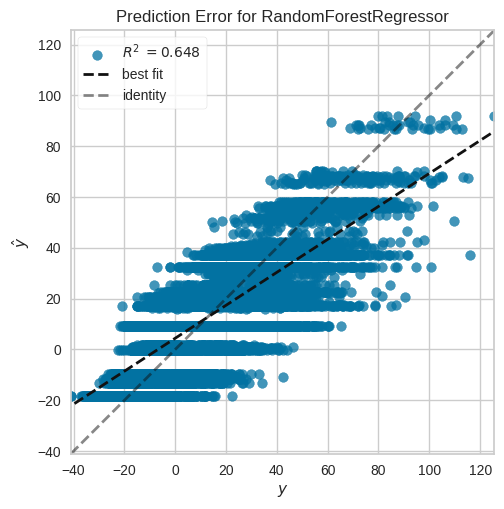

In [90]:
from yellowbrick.regressor import prediction_error

visualizer = prediction_error(modelo, X_train, y_train, X_test, y_test)

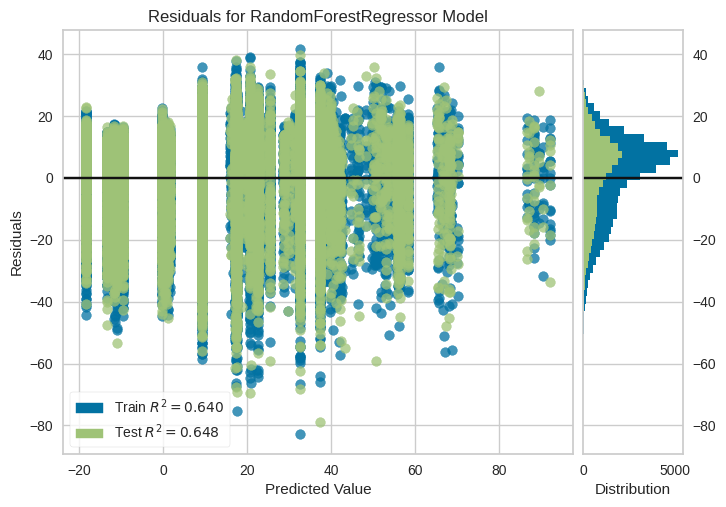

In [91]:
from yellowbrick.regressor import residuals_plot

viz = residuals_plot(modelo, X_train, y_train, X_test, y_test)

In [92]:
from sklearn.model_selection import KFold, cross_validate

scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(modelo, X_train, y_train, cv=cv, scoring=scoring)
cv_results

{'fit_time': array([3.77081037, 3.34049749, 3.050179  , 2.99226975, 4.06152177]),
 'score_time': array([0.083143  , 0.06117082, 0.05880928, 0.05786014, 0.05893159]),
 'test_rmse': array([-13.76989748, -13.86928373, -13.96807668, -13.85347402,
        -13.98953528]),
 'test_mae': array([-11.03252135, -11.13534968, -11.2094657 , -11.14503717,
        -11.25775565]),
 'test_r2': array([0.64559466, 0.63745663, 0.63523823, 0.64089302, 0.63441267])}

In [ ]:
'''
for metric in scoring.keys():
    scores = cv_results[f'test_{metric}']
    mean_score = "{:.3f}".format(scores.mean())
    std_score = "{:.3f}".format(scores.std())

    print(f"{metric.upper()} Scores: {[f'{val:.3f}' for val in scores]}")
    print(f"{metric.upper()} Media: {mean_score}, Std: {std_score}")
    print('----------------------------------------------------------------')

## Otimizacón de Hiperparámtros

In [93]:
len(df.columns)

31

In [102]:
modelo.feature_importances_

array([3.39814918e-06, 3.60417588e-02, 1.45895991e-01, 6.10861947e-05,
       5.30319673e-01, 1.36989042e-05, 2.14417900e-05, 1.00746574e-01,
       5.76173558e-02, 5.18974843e-04, 8.83162236e-05, 2.64390542e-02,
       4.58830752e-02, 1.01922847e-04, 1.71891675e-04, 1.59736760e-02,
       3.57450957e-05, 9.21269997e-05, 5.42552087e-04, 1.03212932e-02,
       2.09099647e-02, 6.63707069e-03, 2.64070312e-04, 8.68597522e-04,
       1.00052465e-04, 2.79146627e-05, 7.17673254e-05, 3.72705034e-05,
       1.06499638e-04, 8.71862374e-05])

In [94]:
#porcentaje de importancia de cada array
importances = modelo.feature_importances_

In [95]:
feature_importances= pd.DataFrame({'Features': X.columns,'Importances': (importances*100).round(2)}).sort_values('Importances', ascending=False)
feature_importances

,Features,Importances
4,airline_BZ,53.03
2,is_holiday,14.59
7,aircraft_type_Airbus A320,10.07
8,aircraft_type_Airbus A330,5.76
12,aircraft_type_Embraer E175,4.59
1,arrival_time,3.60
11,aircraft_type_Boeing 787,2.64
20,origin_TCY,2.09
15,origin_CSF,1.60
19,origin_PUA,1.03


In [97]:
resultados = pd.DataFrame(index=['RMSE', 'MAE','R2'])
model_features = RandomForestRegressor(max_depth=5, random_state=42)
ct_features = [i if i!=0 else 1 for i in range(0,35,5)]

for i in ct_features:
  selected_features = feature_importances['Features'].values [:i]
  X_train_sel = X_train[selected_features]
  X_test_sel = X_test[selected_features]
  model_features.fit(X_train_sel, y_train)
  y_pred =model_features.predict(X_test_sel)
  metricas = calcular_regresion(y_test, y_pred)
  resultados[i]= list(metricas.values())

resultados

,1,5,10,15,20,25,30
RMSE,18.8331,15.1564,13.7587,13.7497,13.7498,13.7477,13.7479
MAE,14.9620,12.0605,11.0422,11.0285,11.0280,11.0261,11.0262
R2,0.3388,0.5718,0.6471,0.6476,0.6476,0.6477,0.6477


In [98]:
resultados = pd.DataFrame(index=['RMSE', 'MAE','R2'])
model_features = RandomForestRegressor(max_depth=5, random_state=42)
ct_features = range(10,16)

for i in ct_features:
  selected_features = feature_importances['Features'].values [:i]
  X_train_sel = X_train[selected_features]
  X_test_sel = X_test[selected_features]
  model_features.fit(X_train_sel, y_train)
  y_pred =model_features.predict(X_test_sel)
  metricas = calcular_regresion(y_test, y_pred)
  resultados[i]= list(metricas.values())

resultados

,10,11,12,13,14,15
RMSE,13.7587,13.7564,13.7526,13.7526,13.7497,13.7497
MAE,11.0422,11.0425,11.0312,11.0314,11.0285,11.0285
R2,0.6471,0.6472,0.6474,0.6474,0.6476,0.6476


In [100]:
selected_features = feature_importances['Features'].values [:13]
X_selected_features =  X[selected_features]
X_selected_features

,airline_BZ,is_holiday,aircraft_type_Airbus A320,aircraft_type_Airbus A330,aircraft_type_Embraer E175,arrival_time,aircraft_type_Boeing 787,origin_TCY,origin_CSF,origin_PUA,origin_TZF,day_name_Friday,origin_MWL
0,0,0,1,0,0,8.885071,0,1,0,0,0,1,0
1,0,0,1,0,0,8.939996,0,1,0,0,0,1,0
2,1,0,0,0,1,18.635384,0,0,0,0,1,1,0
3,1,0,0,1,0,15.967963,0,0,0,0,0,1,0
4,1,0,0,1,0,16.571894,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71170,1,1,0,0,1,18.635384,0,0,0,0,1,0,0
71171,1,1,0,1,0,16.718722,0,0,0,0,0,0,0
71172,0,1,0,0,0,8.564949,1,0,0,0,1,0,0
71173,1,1,1,0,0,9.344097,0,0,0,0,0,0,0


In [104]:
X_train, X_test, y_train, y_test = train_test_split(X_selected_features, y,random_state=42 )

In [106]:
param_grid = {
      'max_depth': [5, 10, 15],
      'min_samples_leaf': [1, 2, 3],
      'min_samples_split': [2, 4, 6],
      'n_estimators': [100, 150, 200]
 }

In [107]:
from sklearn.model_selection import GridSearchCV

cv = KFold(n_splits=5, shuffle=True, random_state=42)

model_grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid=param_grid,
             scoring='r2', cv=cv)

model_grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [5, 10, 15],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 4, 6],
                         'n_estimators': [100, 150, 200]},
             scoring='r2')

In [108]:
model_grid.best_params_

{'max_depth': 10,
 'min_samples_leaf': 3,
 'min_samples_split': 2,
 'n_estimators': 200}

In [110]:
y_pred_model_grid = model_grid.predict(X_test)
metricas_model_grid = calcular_regresion(y_test, y_pred_model_grid)
metricas_model_grid

{'RMSE': 13.2308, 'MAE': 10.6296, 'R2': 0.6754}

In [112]:
resultados['modelo_grid']= list(metricas_model_grid.values())
resultados

,10,11,12,13,14,15,modeo_grid
RMSE,13.7587,13.7564,13.7526,13.7526,13.7497,13.7497,13.2308
MAE,11.0422,11.0425,11.0312,11.0314,11.0285,11.0285,10.6296
R2,0.6471,0.6472,0.6474,0.6474,0.6476,0.6476,0.6754


In [113]:
import pickle

try:
  with open('champion.pkl', 'wb') as file:
    pickle.dump(model_grid.best_estimator_, file)
  print('¡Modelo guardado con éxito!!!')
except Exception as e:
  print('Ocurrió un error al guardar el modelo: ', str(e))

¡Modelo guardado con éxito!!!


In [114]:
nueva_muestra = [0.0, 10.8941, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]

In [116]:
file_path = '/content/champion.pkl'

try:
    with open(file_path, 'rb') as file:
        model = pickle.load(file)
    print("¡Modelo cargado con éxito!")
except Exception as e:
    print("Ocurrió un error al cargar el modelo:", str(e))

¡Modelo cargado con éxito!


In [118]:
# Ejemplo de predicción con datos de entrada 'X'
model.predict([nueva_muestra])[0]

np.float64(48.73321005358915)